# CAST Training & Performance Visualizations



## 1. Setup

In [ ]:
import json, os, warnings, glob
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from math import pi

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi":150,"savefig.dpi":300,"font.family":"sans-serif","font.size":10,"axes.titlesize":12,"axes.labelsize":10})

from google.colab import drive
drive.mount("/content/drive")

BASE = "/content/drive/MyDrive/EmotionDetection/CAST_checkpoints"
OUT = f"{BASE}/Visualisations/training_vis"
os.makedirs(OUT, exist_ok=True)

LO = ["eng","hin","rus","hau","kin","sun","yor","vmw","pcm"]
LN = {"eng":"English","hin":"Hindi","rus":"Russian","hau":"Hausa","kin":"Kinyarwanda","sun":"Sundanese","yor":"Yoruba","vmw":"Emakhuwa","pcm":"Nig. Pidgin"}
EMO = ["anger","disgust","fear","joy","sadness","surprise"]
TI = {"eng":1,"hin":1,"rus":1,"hau":2,"kin":2,"sun":2,"yor":3,"vmw":3,"pcm":3}
TC = {1:"#2196F3",2:"#FF9800",3:"#F44336"}
CB,CO,CG,CR,CP,CT = "#1565C0","#E65100","#2E7D32","#C62828","#6A1B9A","#00838F"
print("Setup complete. Output:", OUT)

Mounted at /content/drive
Setup complete. Output: /content/drive/MyDrive/EmotionDetection/CAST_checkpoints/Visualisations/training_vis


## 2. Load data

In [ ]:
with open(f"{BASE}/Phase2/phase2_validation_raw_results_gemma4.json") as f: p2r = json.load(f)
p2sig = pd.read_csv(f"{BASE}/Phase2/phase2_bootstrap_significance.csv")
p2det = pd.read_csv(f"{BASE}/Phase2/phase2_gemma4_detailed.csv")
p2sum = pd.read_csv(f"{BASE}/Phase2/phase2_gemma4_summary.csv")

with open(f"{BASE}/Phase1/xlmr_results/xlmr_track_a.json") as f: p1xa = json.load(f)
with open(f"{BASE}/Phase1/xlmr_results/xlmr_track_c.json") as f: p1xc = json.load(f)
with open(f"{BASE}/Phase1/serengeti/phase1_serengeti.json") as f: p1s = json.load(f)

with open(f"{BASE}/Phase3/phase3_xlmr_validation_scores.json") as f: p3x = json.load(f)
with open(f"{BASE}/Phase3/phase3_serengeti_validation.json") as f: p3s = json.load(f)
p3bc = pd.read_csv(f"{BASE}/Phase3/phase3_backbone_comparison.csv")
p3bs = pd.read_csv(f"{BASE}/Phase3/phase3_backbone_validation_significance.csv")

p4a = pd.read_csv(f"{BASE}/Phase4/phase4_test_ablation_results.csv")
p4i = pd.read_csv(f"{BASE}/Phase4/phase4_interaction_bootstrap.csv")
p4p = pd.read_csv(f"{BASE}/Phase4/phase4_pairwise_bootstrap.csv")

bm = pd.read_csv(f"{BASE}/published_benchmark_reference_by_track.csv")
bma = dict(zip(bm["Language code"].str.lower(), bm["Published Track A best macro-F1"]))
print("All data loaded.")

All data loaded.


## 3. Per-Emotion F1 Heatmap (P0 Baseline)

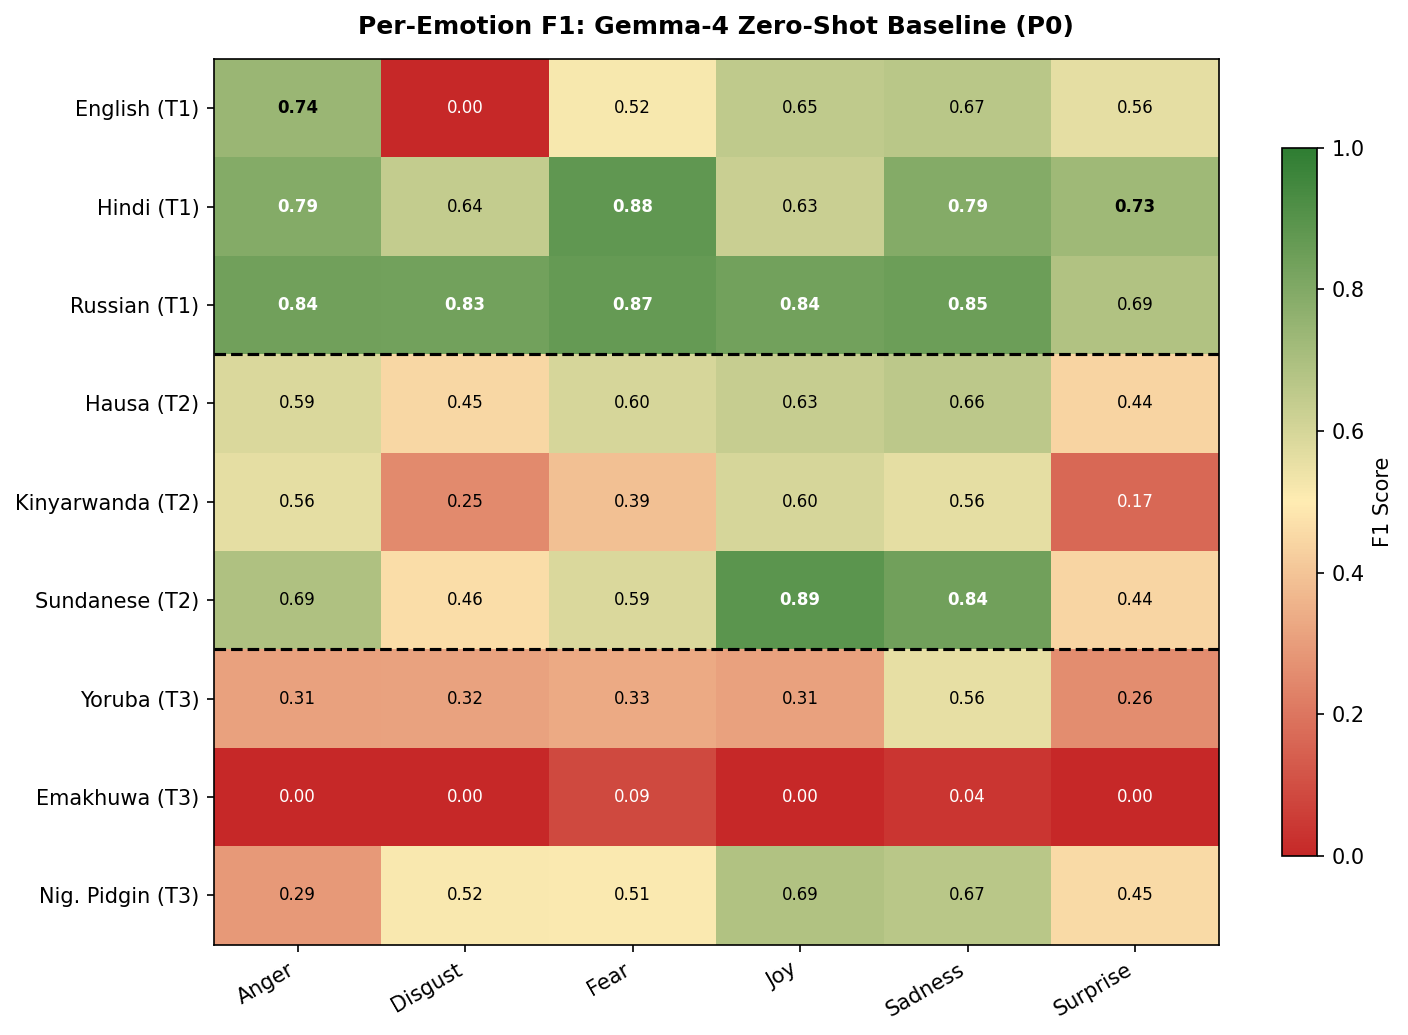

Saved fig01


In [ ]:
fig, ax = plt.subplots(figsize=(10,7))
M = np.array([[p2r[l]["p0"].get(e,0) for e in EMO] for l in LO])
cm = LinearSegmentedColormap.from_list("rg",[CR,"#FFECB3",CG])
im = ax.imshow(M, cmap=cm, vmin=0, vmax=1, aspect="auto")

for i in range(len(LO)):
    for j in range(len(EMO)):
        v=M[i,j]; c="white" if v<0.25 or v>0.75 else "black"
        ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=8,fontweight="bold" if v>0.7 else "normal",color=c)

ax.set_xticks(range(len(EMO))); ax.set_xticklabels([e.capitalize() for e in EMO],rotation=30,ha="right")
ax.set_yticks(range(len(LO))); ax.set_yticklabels([f"{LN[l]} (T{TI[l]})" for l in LO])
ax.axhline(2.5,color="black",lw=1.5,ls="--"); ax.axhline(5.5,color="black",lw=1.5,ls="--")

plt.colorbar(im,ax=ax,shrink=0.8).set_label("F1 Score")
ax.set_title("Per-Emotion F1: Gemma-4 Zero-Shot Baseline (P0)",fontweight="bold",pad=12)
plt.tight_layout(); plt.savefig(f"{OUT}/fig01_emotion_heatmap.png",dpi=300); plt.savefig(f"{OUT}/fig01_emotion_heatmap.pdf"); plt.show()
print("Saved fig01")

## 4. Cultural Prompting Effect Heatmap

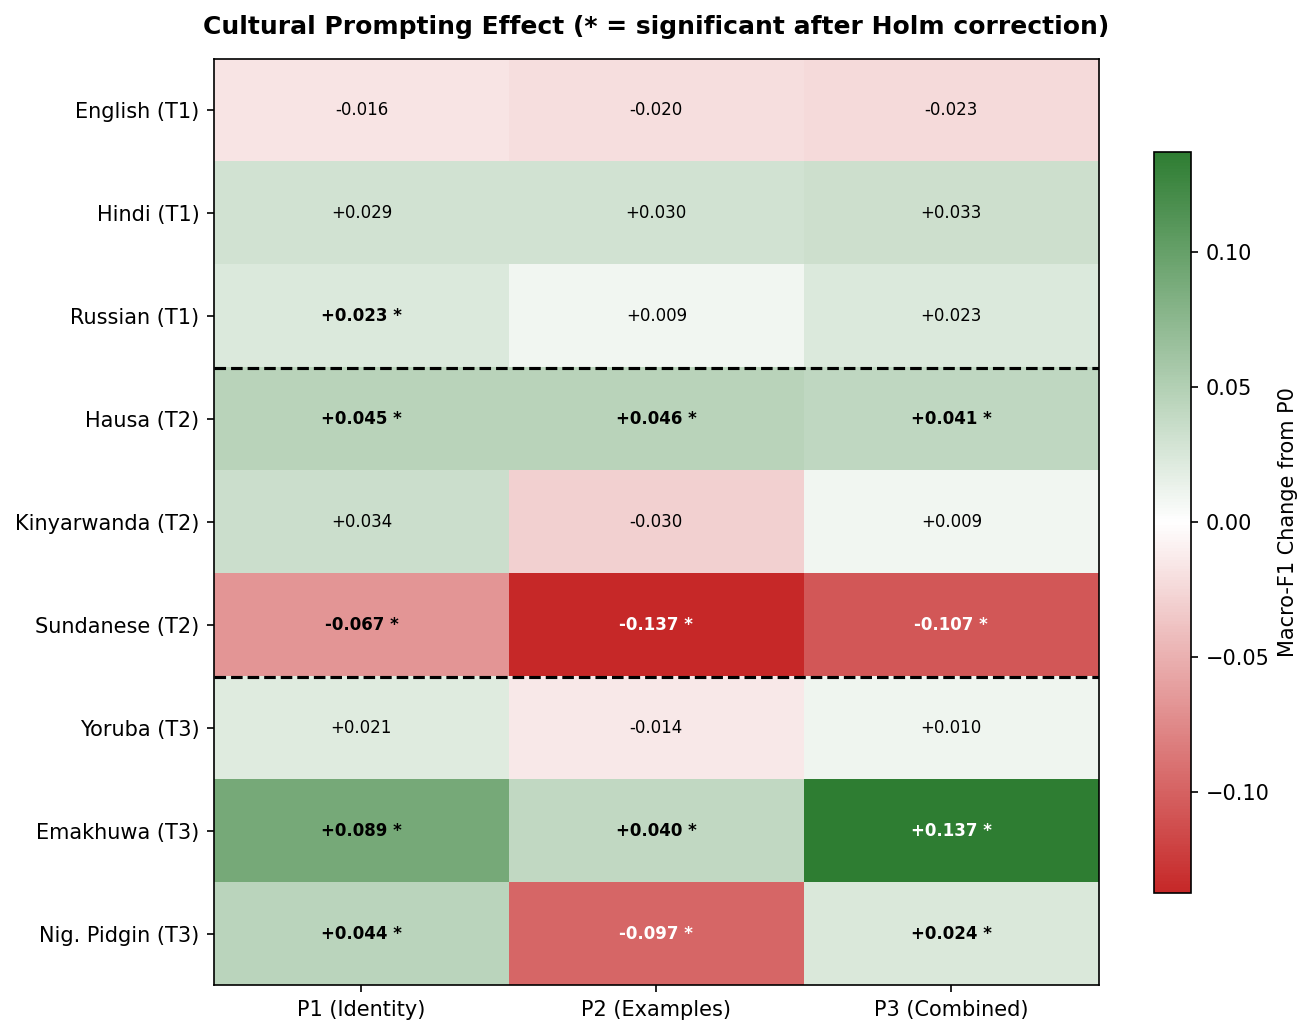

Saved fig02


In [ ]:
fig, ax = plt.subplots(figsize=(9,7))
prompts=["p1","p2","p3"]; plabels=["P1 (Identity)","P2 (Examples)","P3 (Combined)"]
EM = np.array([[p2r[l][p]["macro_f1"]-p2r[l]["p0"]["macro_f1"] for p in prompts] for l in LO])
SM = np.zeros_like(EM,dtype=bool)
for i,l in enumerate(LO):
    for j,p in enumerate(prompts):
        m=(p2sig["Language code"]==l.upper())&(p2sig["Prompt condition"]==p)
        if m.any(): SM[i,j]=p2sig.loc[m,"Significant after Holm correction (alpha=0.05)"].values[0]
ma=max(abs(EM.min()),abs(EM.max()))
cd=LinearSegmentedColormap.from_list("rdgn",[CR,"#FFFFFF",CG])
im=ax.imshow(EM,cmap=cd,vmin=-ma,vmax=ma,aspect="auto")
for i in range(len(LO)):
    for j in range(len(prompts)):
        v=EM[i,j]; s=SM[i,j]; c="black" if abs(v)<ma*0.65 else "white"; mk=" *" if s else ""
        ax.text(j,i,f"{v:+.3f}{mk}",ha="center",va="center",fontsize=8,fontweight="bold" if s else "normal",color=c)
ax.set_xticks(range(len(prompts))); ax.set_xticklabels(plabels)
ax.set_yticks(range(len(LO))); ax.set_yticklabels([f"{LN[l]} (T{TI[l]})" for l in LO])
ax.axhline(2.5,color="black",lw=1.5,ls="--"); ax.axhline(5.5,color="black",lw=1.5,ls="--")
plt.colorbar(im,ax=ax,shrink=0.8).set_label("Macro-F1 Change from P0")
ax.set_title("Cultural Prompting Effect (* = significant after Holm correction)",fontweight="bold",pad=12)
plt.tight_layout(); plt.savefig(f"{OUT}/fig02_cultural_effect_heatmap.png",dpi=300); plt.savefig(f"{OUT}/fig02_cultural_effect_heatmap.pdf"); plt.show()
print("Saved fig02")

## 5. Cultural Prompting Forest Plot (Bootstrap CIs)

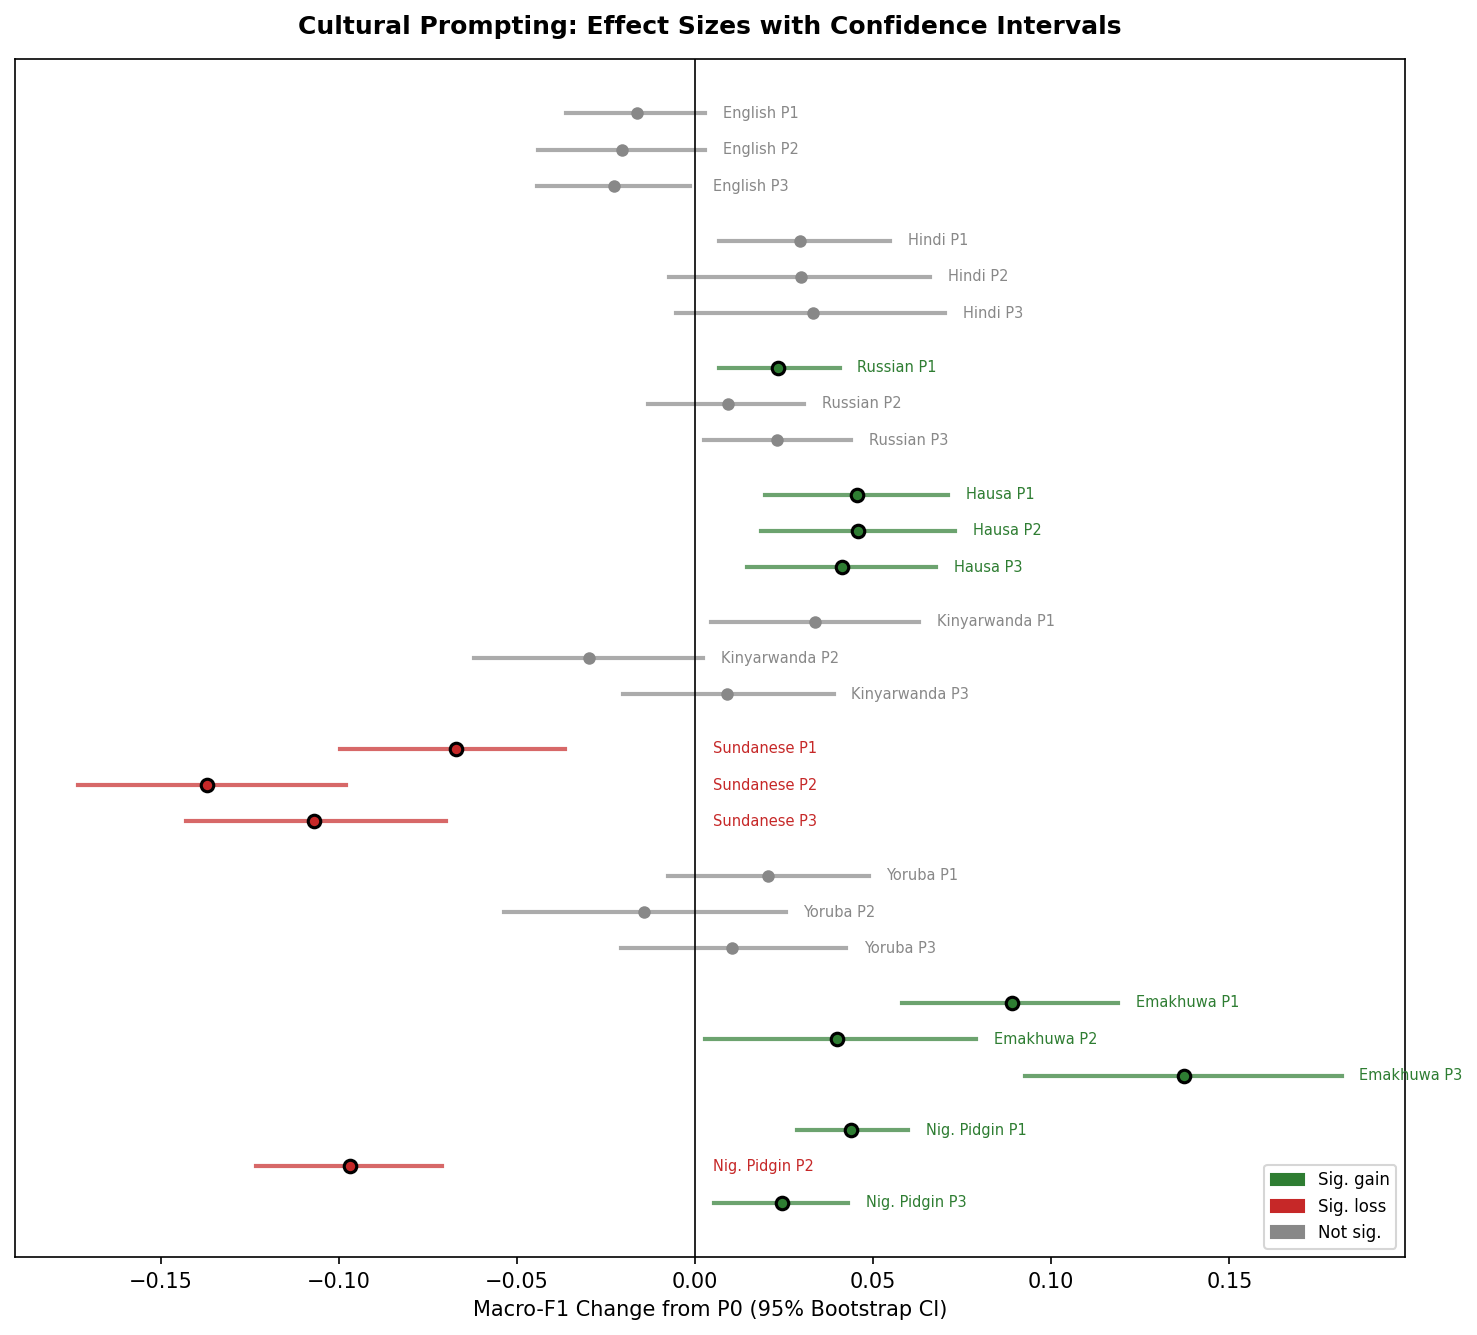

Saved fig03


In [ ]:
fig, ax = plt.subplots(figsize=(10,9))
p2p=p2sig.copy(); lr={l.upper():i for i,l in enumerate(LO)}
p2p["lr"]=p2p["Language code"].map(lr); p2p=p2p.sort_values(["lr","Prompt condition"])
pos=0; prev=None

for _,r in p2p.iterrows():
    l=r["Language code"]
    if prev and l!=prev: pos+=0.5
    prev=l
    eff=r["Prompt effect (compared prompt minus P0)"]; lo=r["95% confidence interval lower bound"]; hi=r["95% confidence interval upper bound"]
    sig=r["Significant after Holm correction (alpha=0.05)"]
    c=CG if (sig and eff>0) else CR if (sig and eff<0) else "#888888"
    ax.plot([lo,hi],[pos,pos],color=c,lw=2,alpha=0.7)
    ax.plot(eff,pos,"o",color=c,ms=6,markeredgecolor="black" if sig else c,markeredgewidth=1.5 if sig else 0)
    ax.text(max(hi,0)+0.005,pos,f"{LN.get(l.lower(),l)} {r['Prompt condition'].upper()}",va="center",fontsize=7,color=c)
    pos+=1

ax.axvline(0,color="black",lw=0.8)
ax.set_xlabel("Macro-F1 Change from P0 (95% Bootstrap CI)"); ax.set_yticks([]); ax.invert_yaxis()
ax.set_title("Cultural Prompting: Effect Sizes with Confidence Intervals",fontweight="bold",pad=12)
ax.legend(handles=[mpatches.Patch(color=CG,label="Sig. gain"),mpatches.Patch(color=CR,label="Sig. loss"),mpatches.Patch(color="#888",label="Not sig.")],loc="lower right",fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT}/fig03_cultural_forest.png",dpi=300); plt.savefig(f"{OUT}/fig03_cultural_forest.pdf"); plt.show()
print("Saved fig03")

## 6. Backbone Comparison: SERENGETI vs XLM-R

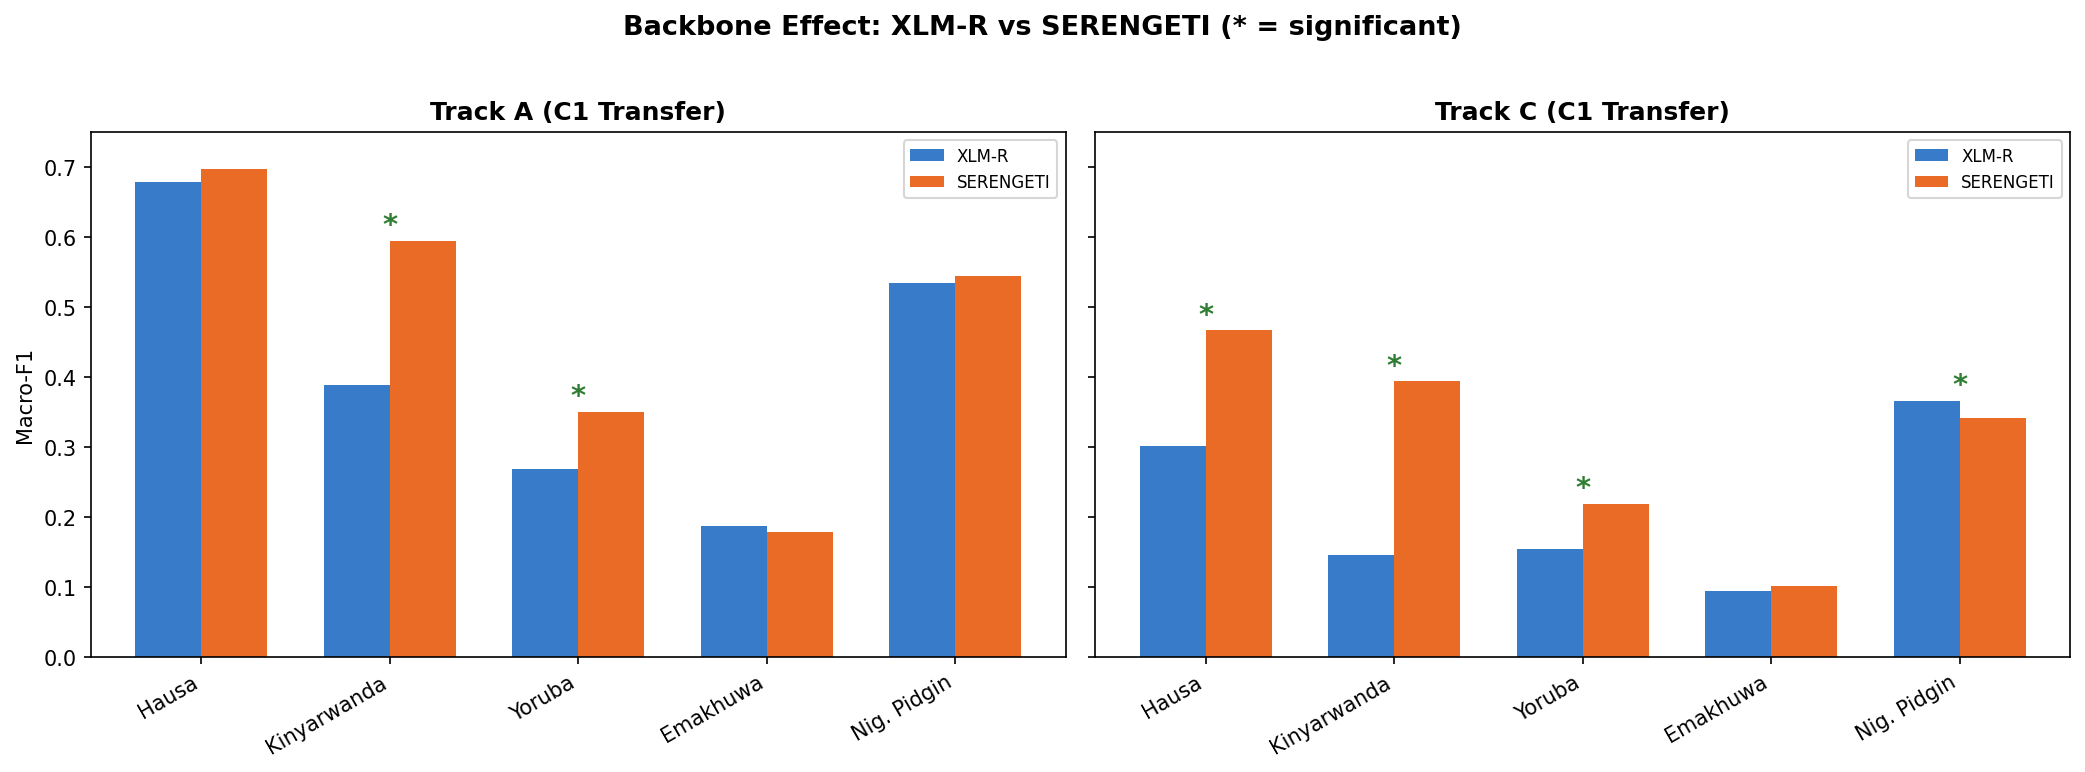

Saved fig04


In [ ]:
af=["HAU","KIN","YOR","VMW","PCM"]
fig,axes=plt.subplots(1,2,figsize=(14,5),sharey=True)
for idx,(trk,ax) in enumerate(zip(["Track A","Track C"],axes)):
    sub=p3bc[(p3bc["Transfer configuration"]=="C1")&(p3bc["Evaluation track"]==trk)]
    sub=sub[sub["Language code"].isin(af)].copy()
    sub["order"]=sub["Language code"].map({l:i for i,l in enumerate(af)})
    sub=sub.sort_values("order")
    x=np.arange(len(sub)); w=0.35
    xv=sub["XLM-R macro-F1"].fillna(0).values; sv=sub["SERENGETI macro-F1"].fillna(0).values
    ax.bar(x-w/2,xv,w,label="XLM-R",color=CB,alpha=0.85)
    ax.bar(x+w/2,sv,w,label="SERENGETI",color=CO,alpha=0.85)
    for i,lc in enumerate(sub["Language code"].values):
        sr=p3bs[(p3bs["Language code"]==lc)&(p3bs["Transfer configuration"]=="C1")&(p3bs["Evaluation track"]==trk)]
        if len(sr)>0 and sr.iloc[0].get("Significant after Holm correction (alpha=0.05)",False):
            ax.text(i,max(xv[i],sv[i])+0.01,"*",ha="center",fontsize=14,fontweight="bold",color=CG)
    ax.set_xticks(x); ax.set_xticklabels([LN.get(l.lower(),l) for l in sub["Language code"]],rotation=30,ha="right")
    ax.set_ylabel("Macro-F1" if idx==0 else ""); ax.set_title(f"{trk} (C1 Transfer)",fontweight="bold"); ax.legend(fontsize=8); ax.set_ylim(0,0.75)
fig.suptitle("Backbone Effect: XLM-R vs SERENGETI (* = significant)",fontweight="bold",fontsize=13,y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig04_backbone_comparison.png",dpi=300,bbox_inches="tight"); plt.savefig(f"{OUT}/fig04_backbone_comparison.pdf",bbox_inches="tight"); plt.show()
print("Saved fig04")

## 7. Backbone Effect Waterfall

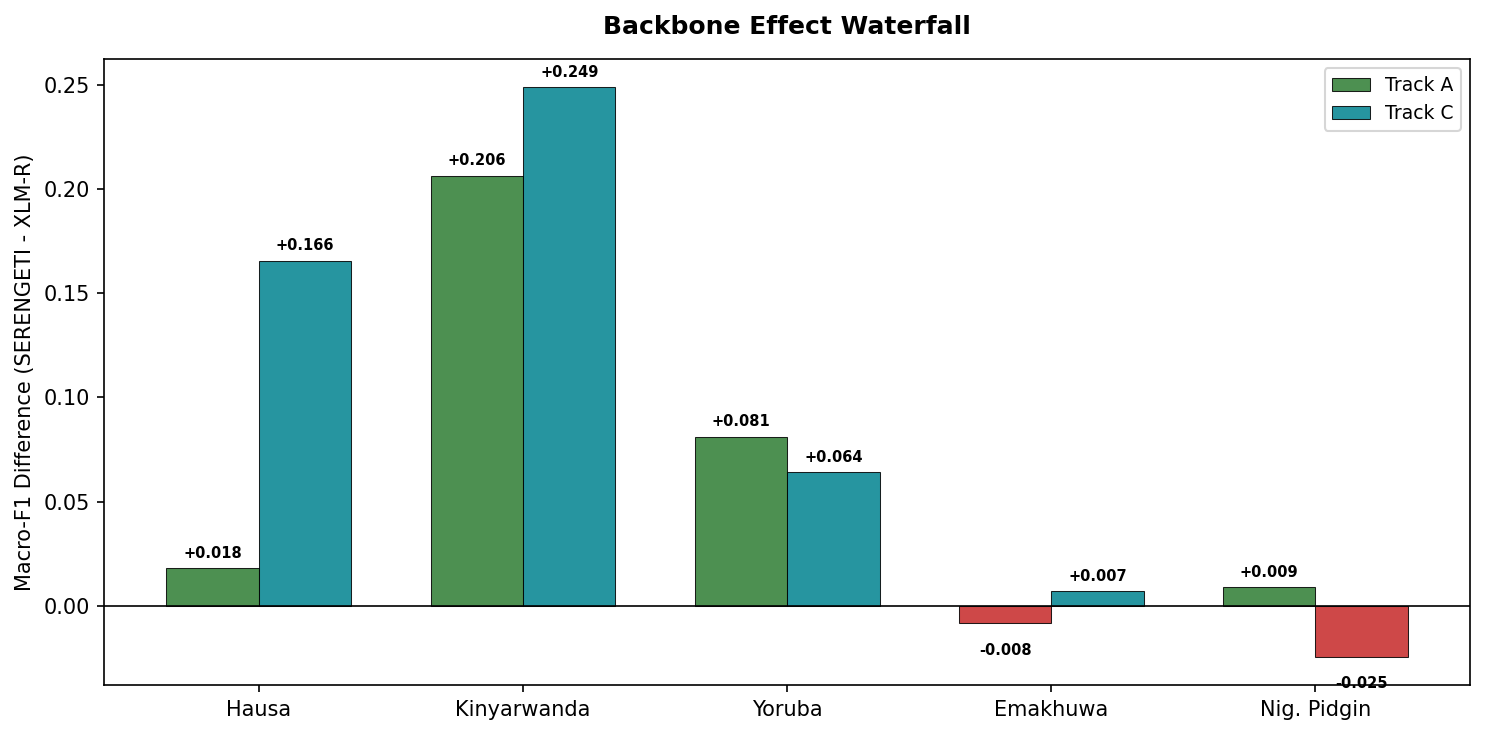

Saved fig05


In [ ]:
fig,ax=plt.subplots(figsize=(10,5))
af=["HAU","KIN","YOR","VMW","PCM"]; x=np.arange(len(af)); w=0.35
ea=[]; ec=[]
for lc in af:
    ra=p3bc[(p3bc["Language code"]==lc)&(p3bc["Transfer configuration"]=="C1")&(p3bc["Evaluation track"]=="Track A")]
    rc=p3bc[(p3bc["Language code"]==lc)&(p3bc["Transfer configuration"]=="C1")&(p3bc["Evaluation track"]=="Track C")]
    va=ra["Backbone effect (SERENGETI minus XLM-R)"].values[0] if len(ra)>0 else 0
    vc=rc["Backbone effect (SERENGETI minus XLM-R)"].values[0] if len(rc)>0 else 0
    ea.append(va if not np.isnan(va) else 0); ec.append(vc if not np.isnan(vc) else 0)
ca=[CG if e>0 else CR for e in ea]; cc=[CT if e>0 else CR for e in ec]
ax.bar(x-w/2,ea,w,label="Track A",color=ca,alpha=0.85,edgecolor="black",lw=0.5)
ax.bar(x+w/2,ec,w,label="Track C",color=cc,alpha=0.85,edgecolor="black",lw=0.5)
for i,(va,vc) in enumerate(zip(ea,ec)):
    ax.text(i-w/2,va+(0.005 if va>=0 else -0.015),f"{va:+.3f}",ha="center",fontsize=7,fontweight="bold")
    ax.text(i+w/2,vc+(0.005 if vc>=0 else -0.015),f"{vc:+.3f}",ha="center",fontsize=7,fontweight="bold")
ax.axhline(0,color="black",lw=0.8); ax.set_xticks(x); ax.set_xticklabels([LN.get(l.lower(),l) for l in af],fontsize=10)
ax.set_ylabel("Macro-F1 Difference (SERENGETI - XLM-R)"); ax.set_title("Backbone Effect Waterfall",fontweight="bold",pad=12); ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig(f"{OUT}/fig05_backbone_waterfall.png",dpi=300); plt.savefig(f"{OUT}/fig05_backbone_waterfall.pdf"); plt.show()
print("Saved fig05")

## 8. Transfer Configuration Comparison (C1/C2/C3)

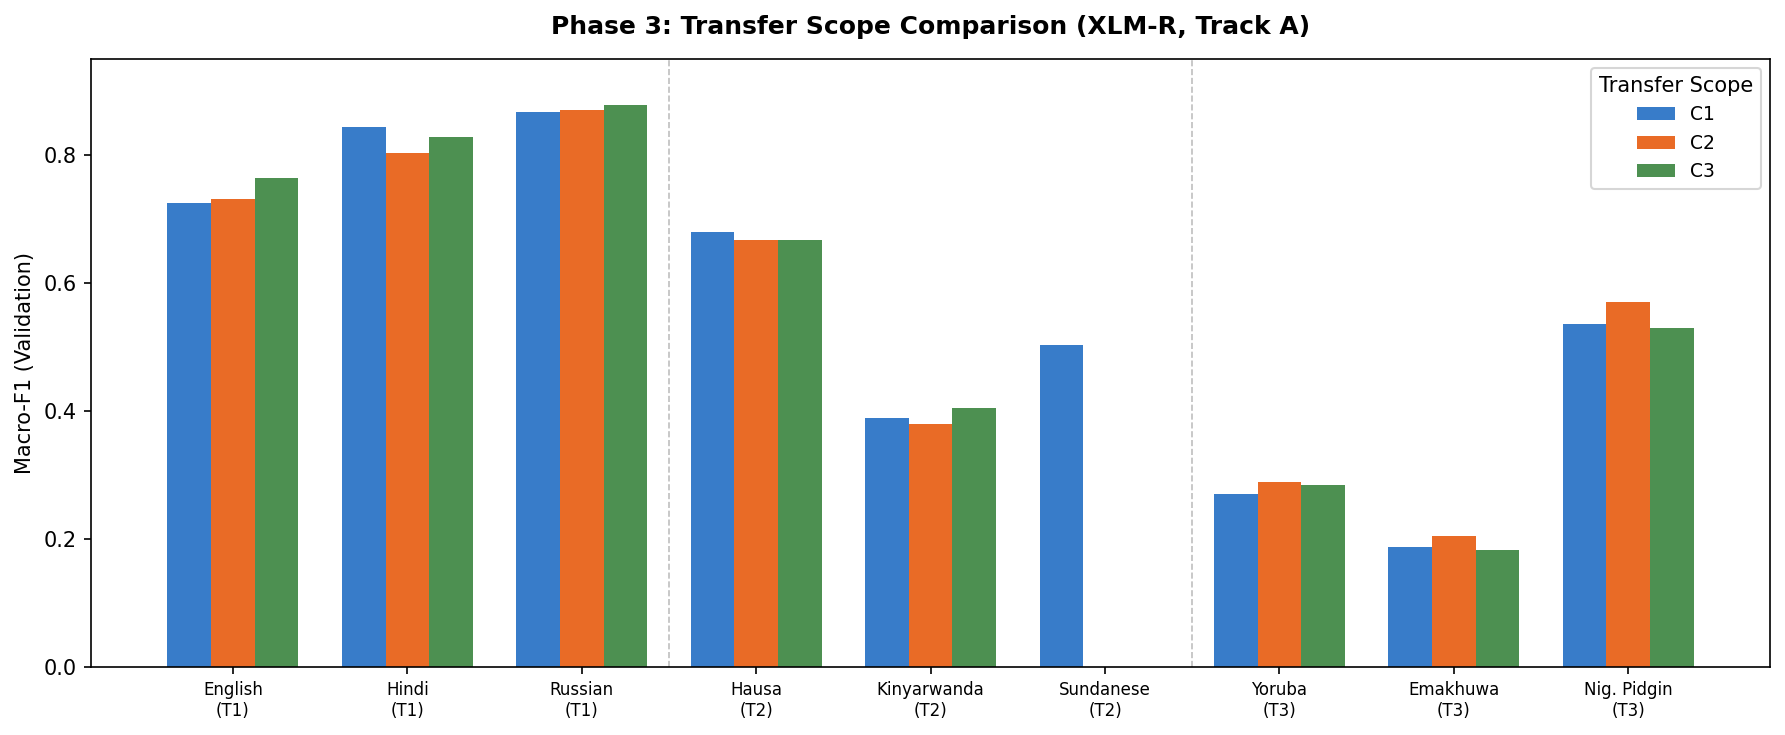

Saved fig06


In [ ]:
fig,ax=plt.subplots(figsize=(12,5))
cfgs=["C1","C2","C3"]; ccols=[CB,CO,CG]; w=0.25; x=np.arange(len(LO))
for ci,(cfg,col) in enumerate(zip(cfgs,ccols)):
    vs=[]
    for l in LO:
        k=f"track_a_{cfg}"
        if l in p3x and k in p3x[l]:
            f1=p3x[l][k].get("macro_f1"); vs.append(f1 if f1 is not None else 0)
        else: vs.append(0)
    ax.bar(x+(ci-1)*w,vs,w,label=cfg,color=col,alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"{LN[l]}\n(T{TI[l]})" for l in LO],fontsize=8)
ax.set_ylabel("Macro-F1 (Validation)"); ax.set_title("Phase 3: Transfer Scope Comparison (XLM-R, Track A)",fontweight="bold",pad=12)
ax.legend(title="Transfer Scope",fontsize=9); ax.set_ylim(0,0.95)
ax.axvline(2.5,color="gray",lw=0.8,ls="--",alpha=0.5); ax.axvline(5.5,color="gray",lw=0.8,ls="--",alpha=0.5)
plt.tight_layout(); plt.savefig(f"{OUT}/fig06_transfer_config.png",dpi=300); plt.savefig(f"{OUT}/fig06_transfer_config.pdf"); plt.show()
print("Saved fig06")

## 9. Phase 4 Ablation

In [ ]:
print("Phase 4 ablation columns:", p4a.columns.tolist())
print(); print(p4a.to_string())

Phase 4 ablation columns: ['Language code', 'Ablation condition', 'Validation-selected prompt', 'Validation-selected transfer configuration', 'Macro-F1', 'Published Track A test best macro-F1 (context only)', 'Published Track C test best macro-F1 (context only)', 'Benchmark comparison status']

   Language code Ablation condition Validation-selected prompt Validation-selected transfer configuration  Macro-F1  Published Track A test best macro-F1 (context only)  Published Track C test best macro-F1 (context only)                                                                           Benchmark comparison status
0            ENG            neither                         p0                                         C3    0.6245                                                0.823                                                0.797  Descriptive context only: Phase 4 is an internal CAST ablation, not an official Track A/C submission
1            ENG        prompt_only                     

Detected: lang=['Language code'], f1=['Macro-F1', 'Published Track A test best macro-F1 (context only)', 'Published Track C test best macro-F1 (context only)'], cond=['Ablation condition']


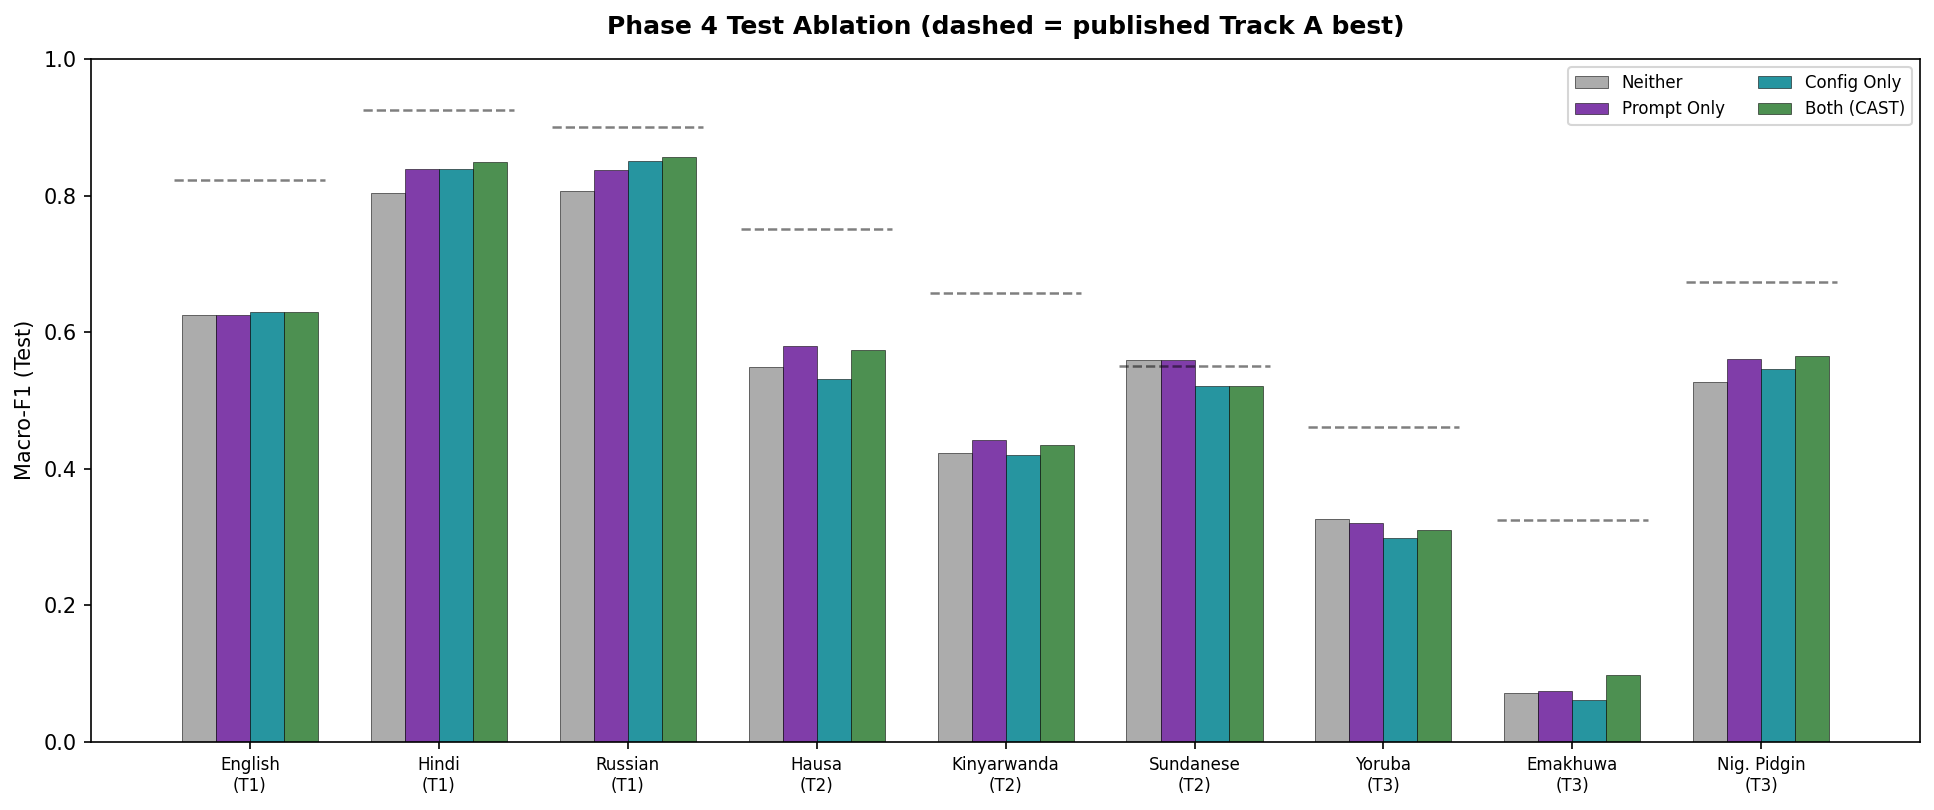

Saved fig07


In [ ]:
# Parse Phase 4 ablation adaptively
fig,ax=plt.subplots(figsize=(13,5.5))
# Identify columns
cols=p4a.columns.tolist()
lang_col=[c for c in cols if "lang" in c.lower() or "code" in c.lower()]
f1_col=[c for c in cols if "macro" in c.lower()]
cond_col=[c for c in cols if any(w in c.lower() for w in ["condition","system","ablation","component"])]
print(f"Detected: lang={lang_col}, f1={f1_col}, cond={cond_col}")

# If it's a wide format (languages as columns or conditions as columns), handle accordingly
# Try to build the ablation data
abl={}
if lang_col and f1_col and cond_col:
    lc=lang_col[0]; fc=f1_col[0]; cc=cond_col[0]
    for _,r in p4a.iterrows():
        lang=str(r[lc]).lower().strip()
        cond=str(r[cc]).lower().strip().replace(" ","_").replace("-","_")
        val=r[fc]
        if lang not in abl: abl[lang]={}
        if pd.notna(val): abl[lang][cond]=float(val)
elif len(cols)>=3:
    # Try first column as lang, remaining as conditions
    print("Trying alternative parse...")
    for _,r in p4a.iterrows():
        lang=str(r.iloc[0]).lower().strip()
        if lang in LO or lang.upper() in [l.upper() for l in LO]:
            lang=lang.lower()[:3]
            if lang not in abl: abl[lang]={}
            for c in cols[1:]:
                if pd.notna(r[c]):
                    try: abl[lang][c.lower().strip()]=float(r[c])
                    except: pass

if abl:
    # Standardize condition names
    cond_order=[]
    cond_meta={}
    for lang_data in abl.values():
        for c in lang_data:
            if c not in cond_meta:
                cl=c.lower()
                if any(w in cl for w in ["neither","baseline","p0_no","no_prompt_no"]):
                    cond_meta[c]=("Neither","#9E9E9E",0)
                elif any(w in cl for w in ["both","full","cast","combined","prompt_config","prompt_and"]):
                    cond_meta[c]=("Both (CAST)",CG,3)
                elif "prompt" in cl and not any(w in cl for w in ["config","transfer","fewshot","no_prompt"]):
                    cond_meta[c]=("Prompt Only",CP,1)
                elif any(w in cl for w in ["config","transfer","fewshot"]) and "prompt" not in cl:
                    cond_meta[c]=("Config Only",CT,2)
                else:
                    cond_meta[c]=(c,"#666666",4)
    sorted_conds=sorted(cond_meta.items(),key=lambda x:x[1][2])
    w=0.18; x=np.arange(len(LO))
    for ci,(raw,(label,color,_)) in enumerate(sorted_conds):
        vs=[abl.get(l,{}).get(raw,0) for l in LO]
        offset=(ci-len(sorted_conds)/2+0.5)*w
        ax.bar(x+offset,vs,w,label=label,color=color,alpha=0.85,edgecolor="black",lw=0.3)
    for i,l in enumerate(LO):
        b=bma.get(l,0)
        ax.plot([i-0.4,i+0.4],[b,b],color="black",lw=1.2,ls="--",alpha=0.5)
    ax.set_xticks(x); ax.set_xticklabels([f"{LN[l]}\n(T{TI[l]})" for l in LO],fontsize=8)
    ax.set_ylabel("Macro-F1 (Test)"); ax.set_title("Phase 4 Test Ablation (dashed = published Track A best)",fontweight="bold",pad=12)
    ax.legend(fontsize=8,ncol=2); ax.set_ylim(0,1.0)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig07_phase4_ablation.png",dpi=300); plt.savefig(f"{OUT}/fig07_phase4_ablation.pdf"); plt.show()
    print("Saved fig07")
else:
    print("Could not parse ablation data. Check CSV structure manually.")

## 10. Phase 4 Interaction Term

Interaction columns: ['Language', 'Language code', 'Interaction effect: both - prompt-only - config-only + neither', '95% confidence interval lower bound', '95% confidence interval upper bound', 'Raw p-value', 'Holm-adjusted p-value', 'Significant after Holm correction (alpha=0.05)', 'Interaction interpretation', 'Evaluation split', 'Statistical test', 'Analysis scope']
          Language Language code  Interaction effect: both - prompt-only - config-only + neither  95% confidence interval lower bound  95% confidence interval upper bound  Raw p-value  Holm-adjusted p-value  Significant after Holm correction (alpha=0.05) Interaction interpretation Evaluation split                           Statistical test                  Analysis scope
0          English           ENG                                                          0.0000                               0.0000                               0.0000       1.0000                 1.0000                                           Fals

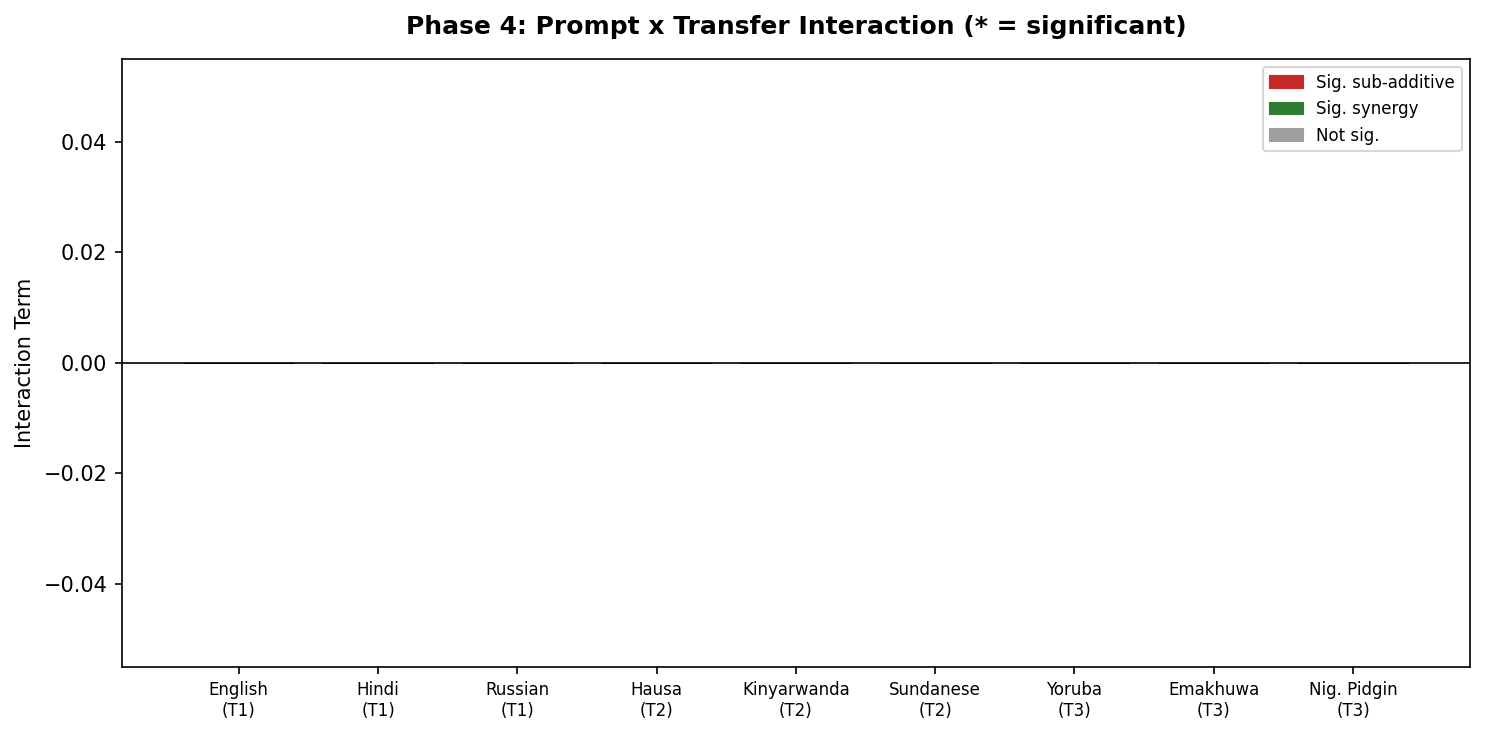

Saved fig08


In [ ]:
fig,ax=plt.subplots(figsize=(10,5))
print("Interaction columns:", p4i.columns.tolist())
print(p4i.to_string())
icols=p4i.columns.tolist()
lc2=[c for c in icols if "lang" in c.lower() or "code" in c.lower()]
ic2=[c for c in icols if "interaction" in c.lower() or "effect" in c.lower() or "term" in c.lower()]
sc2=[c for c in icols if "significant" in c.lower() or "holm" in c.lower()]
if lc2 and ic2:
    lcc=lc2[0]; icc=ic2[0]; scc=sc2[0] if sc2 else None
    vs=[]; ss=[]; ll=[]
    for l in LO:
        r=p4i[p4i[lcc].str.lower()==l]
        if len(r)==0: r=p4i[p4i[lcc].str.upper()==l.upper()]
        if len(r)>0:
            r=r.iloc[0]; vs.append(float(r[icc]))
            ss.append(bool(r[scc]) if scc else False)
        else: vs.append(0); ss.append(False)
        ll.append(LN.get(l,l))
    cs=[CR if (s and v<0) else CG if (s and v>0) else "#9E9E9E" for v,s in zip(vs,ss)]
    x=np.arange(len(LO))
    ax.bar(x,vs,color=cs,alpha=0.85,edgecolor="black",lw=0.5)
    for i,(v,s) in enumerate(zip(vs,ss)):
        if s: ax.text(i,v+(0.003 if v>=0 else -0.008),"*",ha="center",fontsize=16,fontweight="bold")
    ax.axhline(0,color="black",lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels([f"{l}\n(T{TI[LO[i]]})" for i,l in enumerate(ll)],fontsize=8)
    ax.set_ylabel("Interaction Term"); ax.set_title("Phase 4: Prompt x Transfer Interaction (* = significant)",fontweight="bold",pad=12)
    ax.legend(handles=[mpatches.Patch(color=CR,label="Sig. sub-additive"),mpatches.Patch(color=CG,label="Sig. synergy"),mpatches.Patch(color="#9E9E9E",label="Not sig.")],fontsize=8)
    plt.tight_layout(); plt.savefig(f"{OUT}/fig08_interaction.png",dpi=300); plt.savefig(f"{OUT}/fig08_interaction.pdf"); plt.show()
    print("Saved fig08")
else: print("Could not identify interaction columns.")

## 11. Cross-Phase Performance Trajectory

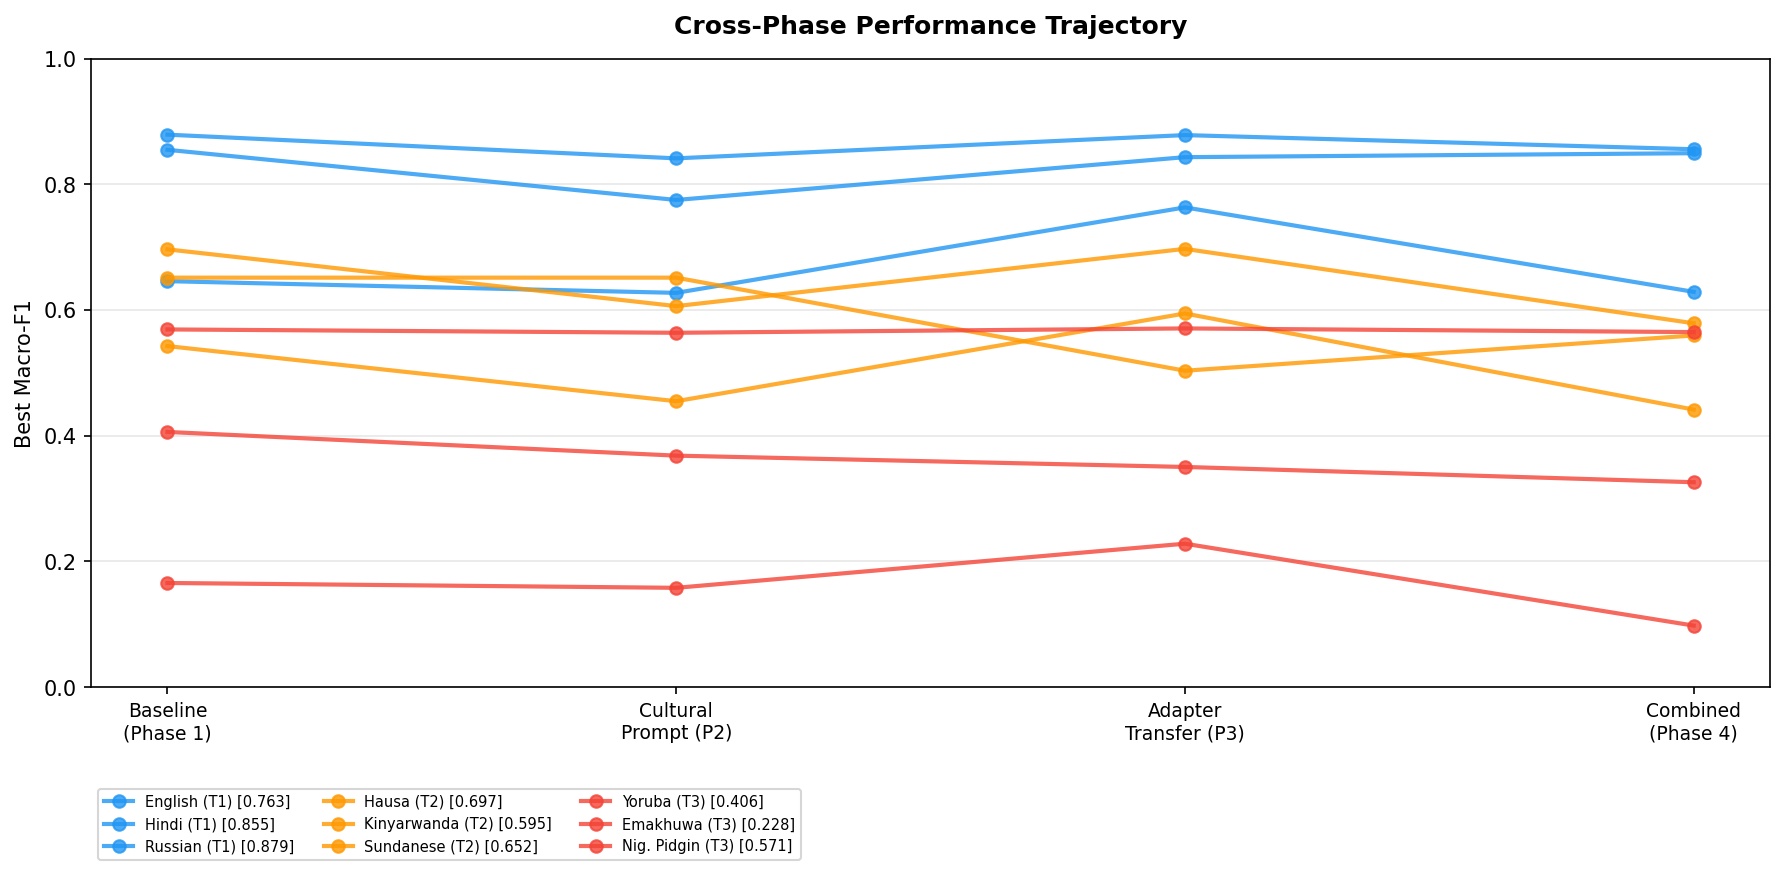

Saved fig09


In [ ]:
fig,ax=plt.subplots(figsize=(12,6))
phases=["Baseline\n(Phase 1)","Cultural\nPrompt (P2)","Adapter\nTransfer (P3)","Combined\n(Phase 4)"]
for l in LO:
    t=TI[l]; c=TC[t]
    # Phase 1 best
    v1=[p2r[l]["p0"]["macro_f1"]]
    if l in p1xa: v1.append(p1xa[l]["macro_f1"])
    if "track_a" in p1s and l in p1s["track_a"]: v1.append(p1s["track_a"][l]["macro_f1"])
    p1b=max(v1)
    # Phase 2 best
    p2b=max(p2r[l][p]["macro_f1"] for p in ["p0","p1","p2","p3"])
    # Phase 3 best
    v3=[]
    for src in [p3x,p3s]:
        if l in src:
            for k in ["track_a_C1","track_a_C2","track_a_C3"]:
                if k in src[l]:
                    f=src[l][k].get("macro_f1")
                    if f is not None: v3.append(f)
    p3b=max(v3) if v3 else p2b
    # Phase 4 best (from parsed ablation or fallback)
    p4v=list(abl.get(l,{}).values()) if abl else []
    p4b=max(p4v) if p4v else p3b
    traj=[p1b,p2b,p3b,p4b]; ob=max(traj)
    ax.plot(range(4),traj,"o-",color=c,lw=2,ms=6,alpha=0.8,label=f"{LN[l]} (T{t}) [{ob:.3f}]")
ax.set_xticks(range(4)); ax.set_xticklabels(phases,fontsize=9)
ax.set_ylabel("Best Macro-F1"); ax.set_title("Cross-Phase Performance Trajectory",fontweight="bold",pad=12)
ax.legend(fontsize=7,ncol=3,loc="upper left",bbox_to_anchor=(0,-0.15)); ax.grid(axis="y",alpha=0.3); ax.set_ylim(0,1.0)
plt.tight_layout(); plt.savefig(f"{OUT}/fig09_trajectory.png",dpi=300,bbox_inches="tight"); plt.savefig(f"{OUT}/fig09_trajectory.pdf",bbox_inches="tight"); plt.show()
print("Saved fig09")

## 12. Per-Emotion Radar Charts

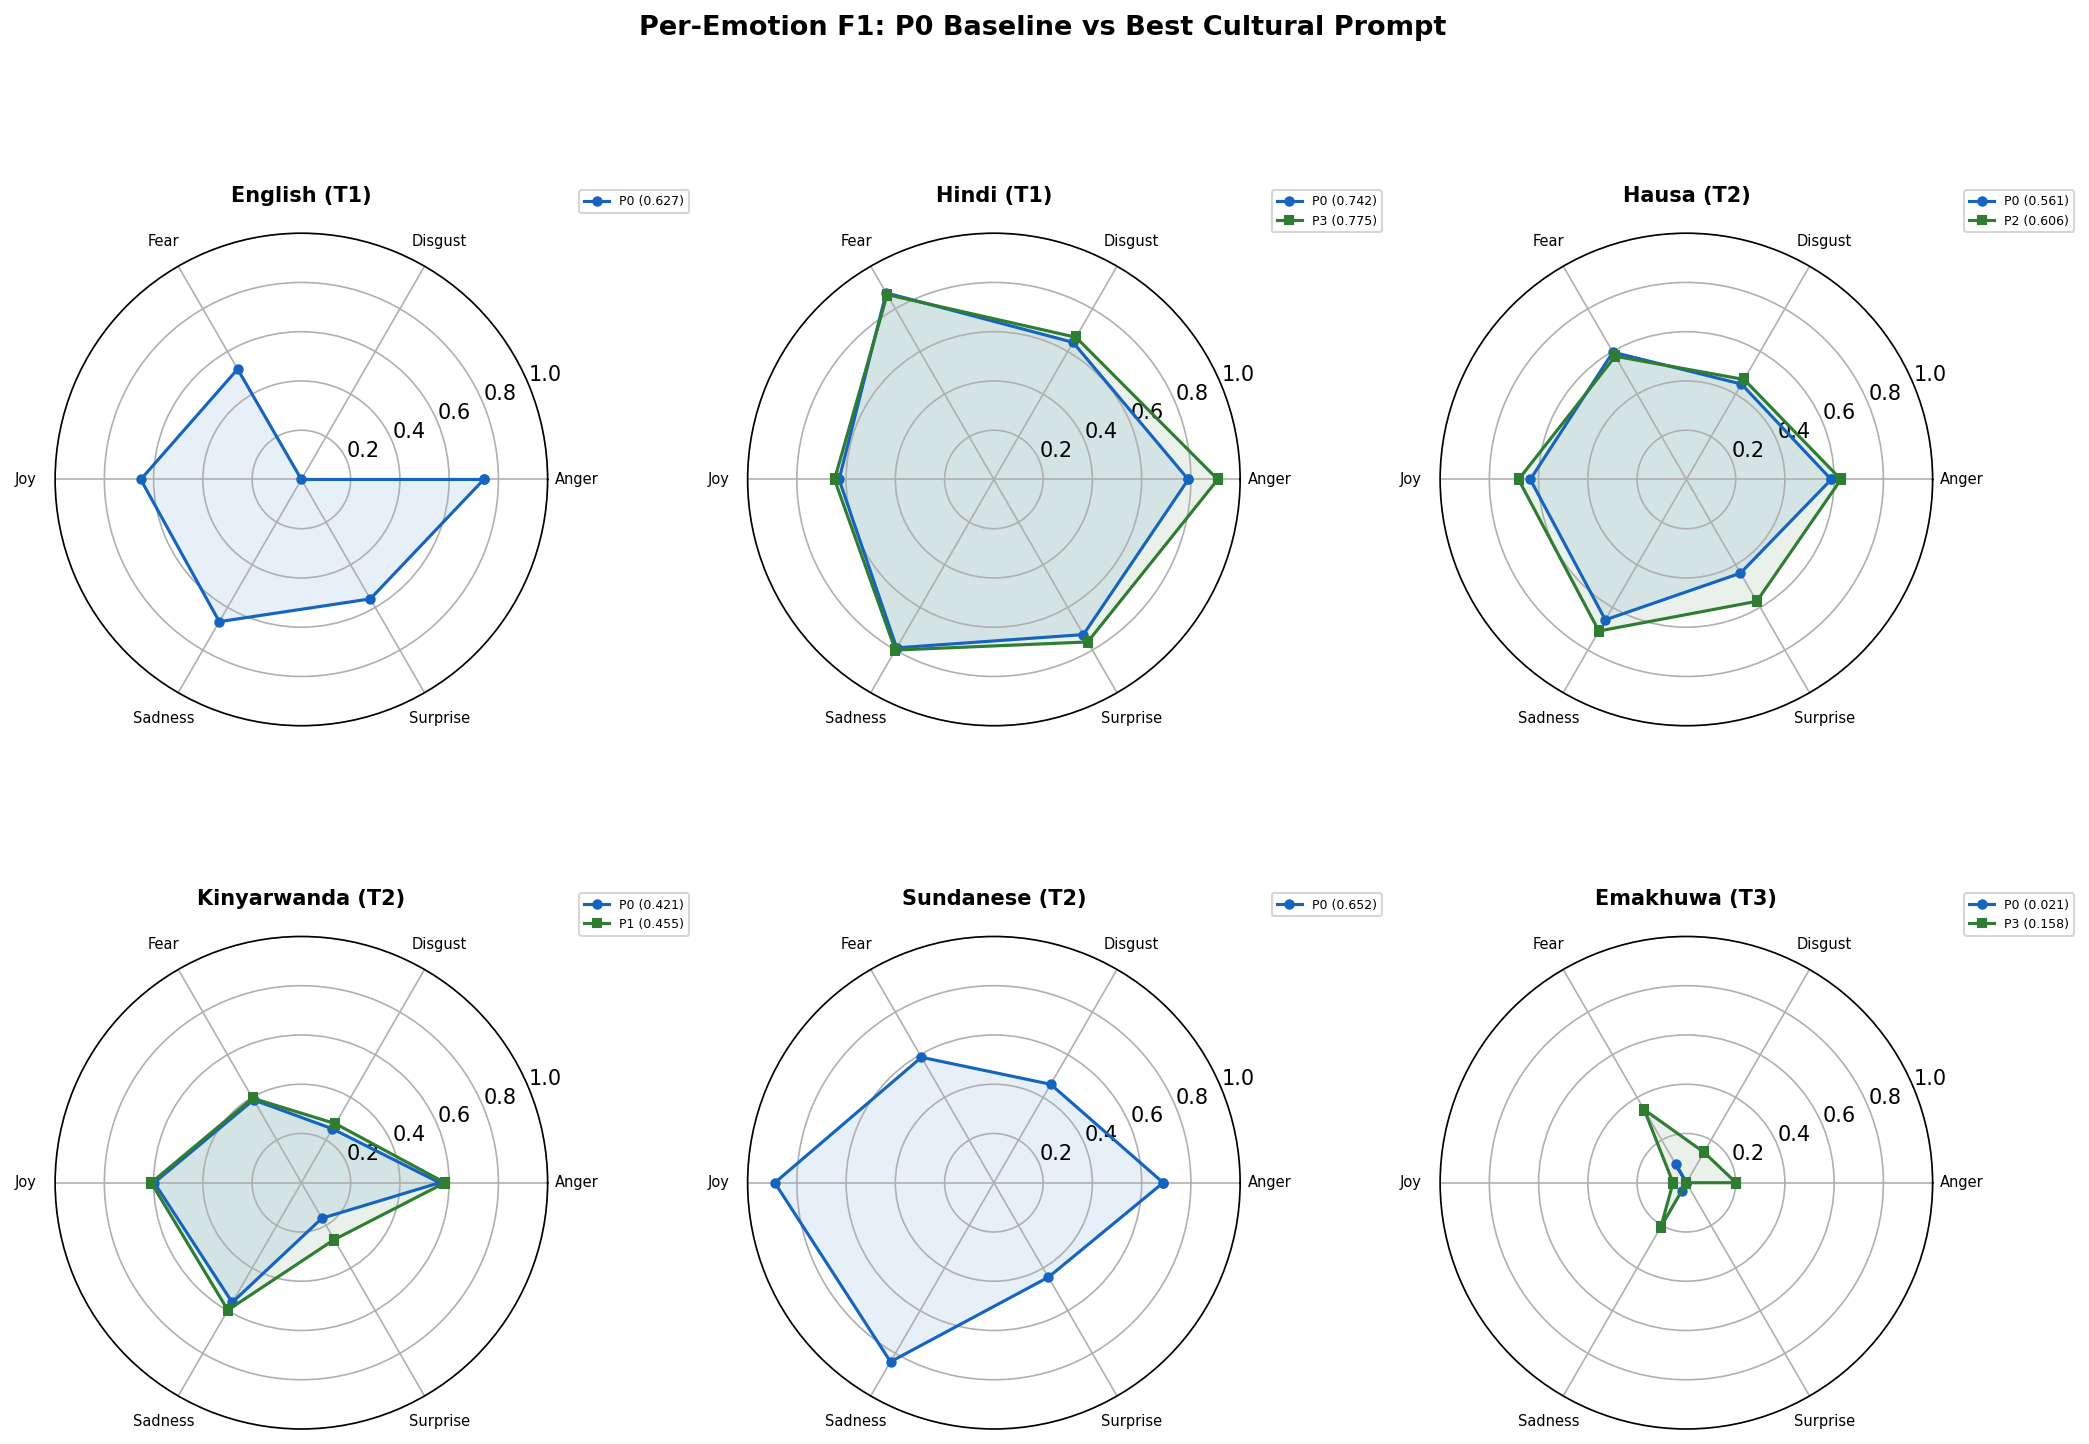

Saved fig10


In [ ]:
sel=["eng","hin","hau","kin","sun","vmw"]
fig,axes=plt.subplots(2,3,figsize=(14,10),subplot_kw=dict(polar=True))
N=len(EMO); ang=[n/float(N)*2*pi for n in range(N)]; ang+=ang[:1]
el=[e.capitalize() for e in EMO]
for lang,ax in zip(sel,axes.flat):
    t=TI[lang]
    p0v=[p2r[lang]["p0"].get(e,0) for e in EMO]+[p2r[lang]["p0"].get(EMO[0],0)]
    bp=max(["p0","p1","p2","p3"],key=lambda p:p2r[lang][p]["macro_f1"])
    bv=[p2r[lang][bp].get(e,0) for e in EMO]+[p2r[lang][bp].get(EMO[0],0)]
    ax.plot(ang,p0v,"o-",color=CB,lw=1.5,ms=4,label=f"P0 ({p2r[lang]['p0']['macro_f1']:.3f})")
    ax.fill(ang,p0v,color=CB,alpha=0.1)
    if bp!="p0":
        ax.plot(ang,bv,"s-",color=CG,lw=1.5,ms=4,label=f"{bp.upper()} ({p2r[lang][bp]['macro_f1']:.3f})")
        ax.fill(ang,bv,color=CG,alpha=0.1)
    ax.set_xticks(ang[:-1]); ax.set_xticklabels(el,fontsize=7); ax.set_ylim(0,1)
    ax.set_title(f"{LN[lang]} (T{t})",fontsize=10,fontweight="bold",pad=15)
    ax.legend(fontsize=6,loc="upper right",bbox_to_anchor=(1.3,1.1))
fig.suptitle("Per-Emotion F1: P0 Baseline vs Best Cultural Prompt",fontsize=13,fontweight="bold",y=1.02)
plt.tight_layout(); plt.savefig(f"{OUT}/fig10_radar.png",dpi=300,bbox_inches="tight"); plt.savefig(f"{OUT}/fig10_radar.pdf",bbox_inches="tight"); plt.show()
print("Saved fig10")

## 13. Resource-Tier Performance Variation


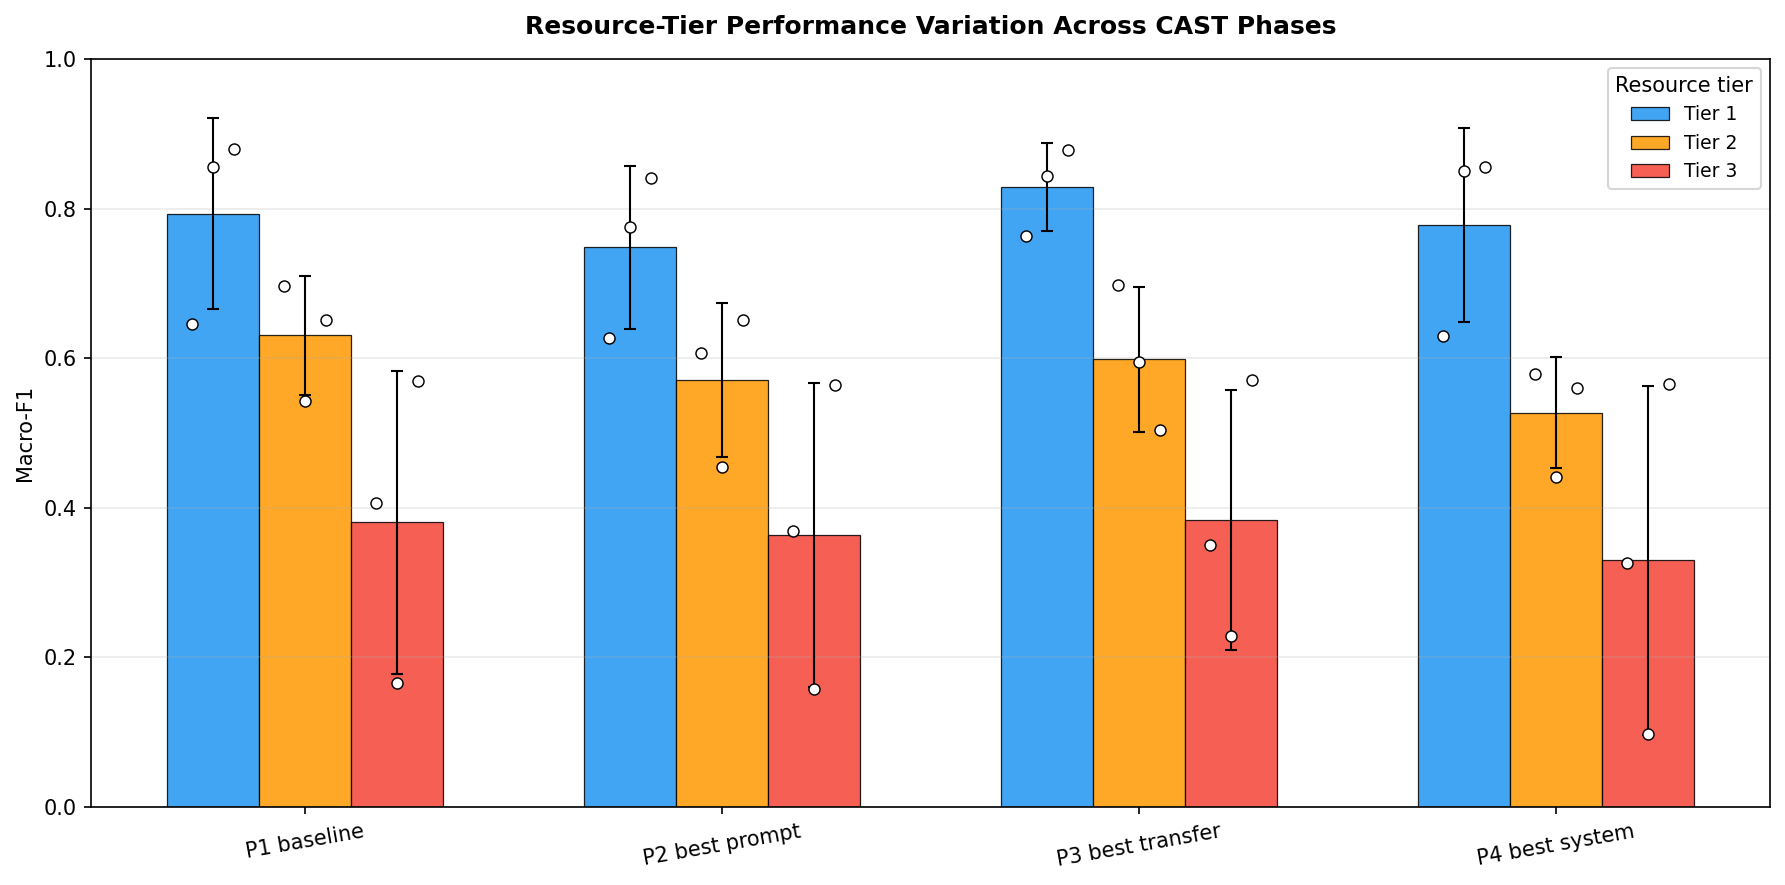

Saved fig11 and supporting CSV files


In [ ]:
# Helper: robust Phase 4 ablation parsing

def parse_ablation_table(df):
    cols = list(df.columns)
    lang_col = next((c for c in cols if "lang" in c.lower() or "code" in c.lower()), None)
    f1_col = next((c for c in cols if "macro" in c.lower()), None)
    cond_col = next((c for c in cols if any(w in c.lower() for w in ["condition", "system", "ablation", "component"])), None)
    out = {}

    if lang_col and f1_col and cond_col:
        for _, row in df.iterrows():
            lang = str(row[lang_col]).lower().strip()[:3]
            cond = (
                str(row[cond_col]).lower().strip()
                .replace(" ", "_")
                .replace("-", "_")
            )
            if pd.notna(row[f1_col]):
                out.setdefault(lang, {})[cond] = float(row[f1_col])
    elif len(cols) >= 3:
        for _, row in df.iterrows():
            lang = str(row.iloc[0]).lower().strip()[:3]
            if lang in LO:
                out.setdefault(lang, {})
                for c in cols[1:]:
                    try:
                        if pd.notna(row[c]):
                            out[lang][str(c).lower().strip()] = float(row[c])
                    except Exception:
                        pass
    return out

P4_ABL = parse_ablation_table(p4a)

def phase1_best_score(lang):
    vals = []
    try:
        vals.append(float(p2r[lang]["p0"]["macro_f1"]))
    except Exception:
        pass
    try:
        vals.append(float(p1xa[lang]["macro_f1"]))
    except Exception:
        pass
    try:
        if "track_a" in p1s and lang in p1s["track_a"]:
            vals.append(float(p1s["track_a"][lang]["macro_f1"]))
    except Exception:
        pass
    return max(vals) if vals else np.nan


def phase2_best_score(lang):
    vals = []
    for prompt_key in ["p0", "p1", "p2", "p3"]:
        try:
            vals.append(float(p2r[lang][prompt_key]["macro_f1"]))
        except Exception:
            pass
    return max(vals) if vals else np.nan


def phase3_best_score(lang):
    vals = []
    for source in [p3x, p3s]:
        if lang not in source:
            continue
        for key, value in source[lang].items():
            if not isinstance(value, dict):
                continue
            score = value.get("macro_f1_raw", value.get("macro_f1"))
            if score is not None and not pd.isna(score):
                vals.append(float(score))
    return max(vals) if vals else np.nan


def phase4_best_score(lang):
    vals = []
    for _, value in P4_ABL.get(lang, {}).items():
        if value is not None and not pd.isna(value):
            vals.append(float(value))
    return max(vals) if vals else np.nan

rows = []
for lang in LO:
    rows.extend([
        {"language": LN[lang], "code": lang.upper(), "tier": f"Tier {TI[lang]}", "phase": "Phase 1 baseline", "score": phase1_best_score(lang)},
        {"language": LN[lang], "code": lang.upper(), "tier": f"Tier {TI[lang]}", "phase": "Phase 2 best prompt", "score": phase2_best_score(lang)},
        {"language": LN[lang], "code": lang.upper(), "tier": f"Tier {TI[lang]}", "phase": "Phase 3 best transfer", "score": phase3_best_score(lang)},
        {"language": LN[lang], "code": lang.upper(), "tier": f"Tier {TI[lang]}", "phase": "Phase 4 best system", "score": phase4_best_score(lang)},
    ])

tier_variation = pd.DataFrame(rows)
tier_variation.to_csv(f"{OUT}/fig11_resource_tier_variation_data.csv", index=False)

phase_order = ["Phase 1 baseline", "Phase 2 best prompt", "Phase 3 best transfer", "Phase 4 best system"]
tier_order = ["Tier 1", "Tier 2", "Tier 3"]
summary = (
    tier_variation.groupby(["tier", "phase"], dropna=False)["score"]
    .agg(mean="mean", std="std", count="count")
    .reset_index()
)
summary["std"] = summary["std"].fillna(0)
summary.to_csv(f"{OUT}/fig11_resource_tier_variation_summary.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.22
x = np.arange(len(phase_order))
offsets = {"Tier 1": -bar_width, "Tier 2": 0.0, "Tier 3": bar_width}

for tier in tier_order:
    tier_mean = []
    tier_std = []
    for phase in phase_order:
        match = summary[(summary["tier"] == tier) & (summary["phase"] == phase)]
        tier_mean.append(float(match["mean"].iloc[0]) if len(match) else np.nan)
        tier_std.append(float(match["std"].iloc[0]) if len(match) else 0.0)
    xpos = x + offsets[tier]
    ax.bar(xpos, tier_mean, width=bar_width, label=tier, color=TC[int(tier[-1])], alpha=0.85, edgecolor="black", linewidth=0.6)
    ax.errorbar(xpos, tier_mean, yerr=tier_std, fmt="none", ecolor="black", elinewidth=1, capsize=3)

    tier_points = tier_variation[tier_variation["tier"] == tier].copy()
    for i, phase in enumerate(phase_order):
        vals = tier_points[tier_points["phase"] == phase]["score"].dropna().tolist()
        if not vals:
            continue
        if len(vals) == 1:
            jitters = [0.0]
        else:
            jitters = np.linspace(-0.05, 0.05, len(vals))
        for j, value in enumerate(vals):
            ax.scatter(xpos[i] + jitters[j], value, s=28, color="white", edgecolor="black", linewidth=0.7, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels([p.replace("Phase ", "P") for p in phase_order], rotation=10)
ax.set_ylabel("Macro-F1")
ax.set_title("Resource-Tier Performance Variation Across CAST Phases", fontweight="bold", pad=12)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend(title="Resource tier", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/fig11_resource_tier_variation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT}/fig11_resource_tier_variation.pdf", bbox_inches="tight")
plt.show()

print("Saved fig11 and supporting CSV files")


## 14. Per-Emotion Effect / Contribution Analysis


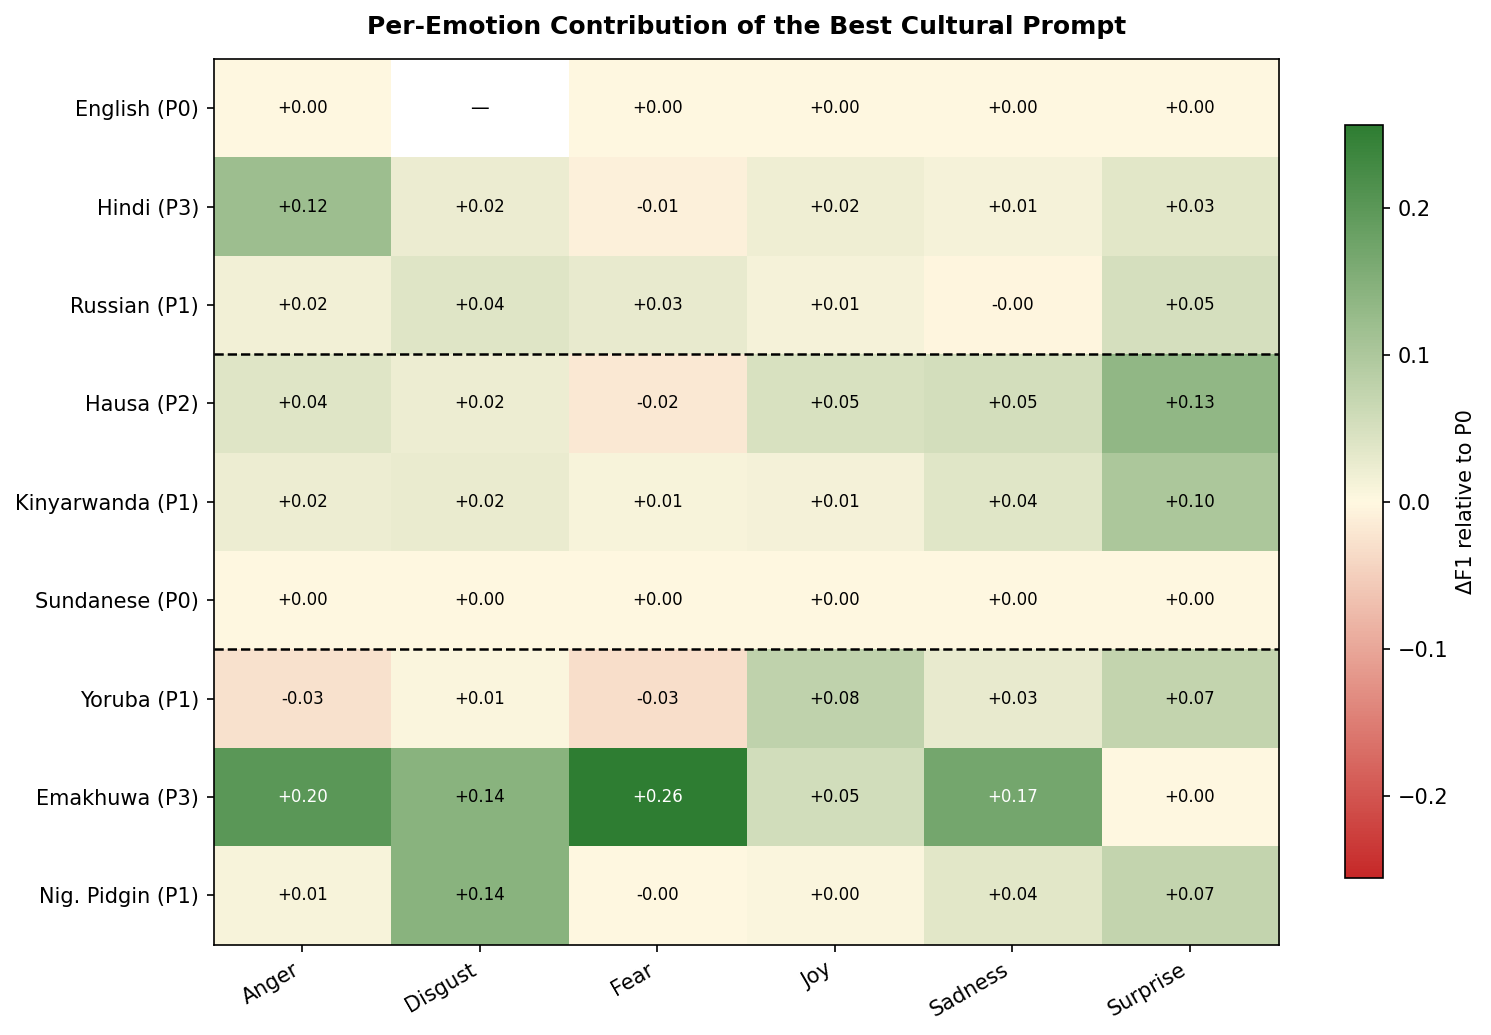

 emotion  mean_delta  median_delta  n
   anger    0.042133        0.0155  9
 disgust    0.050075        0.0240  8
    fear    0.025644        0.0000  9
     joy    0.024944        0.0125  9
 sadness    0.036222        0.0272  9
surprise    0.051533        0.0502  9
Saved fig12 and supporting CSV files


In [ ]:
def eval_emotions(lang_code):
    return [emotion for emotion in EMO if not (lang_code == "eng" and emotion == "disgust")]

emotion_rows = []
for lang in LO:
    best_prompt = max(["p0", "p1", "p2", "p3"], key=lambda p: p2r[lang][p]["macro_f1"])
    for emotion in EMO:
        if emotion not in eval_emotions(lang):
            delta = np.nan
        else:
            delta = float(p2r[lang][best_prompt].get(emotion, np.nan)) - float(p2r[lang]["p0"].get(emotion, np.nan))
        emotion_rows.append({
            "language": LN[lang],
            "code": lang.upper(),
            "tier": f"Tier {TI[lang]}",
            "best_prompt": best_prompt.upper(),
            "emotion": emotion,
            "delta_f1": delta,
        })

emotion_effect = pd.DataFrame(emotion_rows)
emotion_effect.to_csv(f"{OUT}/fig12_per_emotion_effect_data.csv", index=False)

heat = (
    emotion_effect
    .pivot(index="language", columns="emotion", values="delta_f1")
    .reindex([LN[l] for l in LO])
    .reindex(columns=EMO)
)

vmax = np.nanmax(np.abs(heat.to_numpy(dtype=float)))
if not np.isfinite(vmax) or vmax == 0:
    vmax = 0.05

fig, ax = plt.subplots(figsize=(10.5, 7))
cm = LinearSegmentedColormap.from_list("delta_rg", [CR, "#FFF8E1", CG])
im = ax.imshow(heat.to_numpy(dtype=float), cmap=cm, vmin=-vmax, vmax=vmax, aspect="auto")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        value = heat.iloc[i, j]
        if pd.isna(value):
            ax.text(j, i, "—", ha="center", va="center", fontsize=9, color="black")
        else:
            color = "white" if abs(value) > (0.6 * vmax) else "black"
            ax.text(j, i, f"{value:+.2f}", ha="center", va="center", fontsize=8, color=color)

best_prompt_labels = []
for lang in LO:
    bp = max(["p0", "p1", "p2", "p3"], key=lambda p: p2r[lang][p]["macro_f1"]).upper()
    best_prompt_labels.append(f"{LN[lang]} ({bp})")

ax.set_xticks(np.arange(len(EMO)))
ax.set_xticklabels([e.capitalize() for e in EMO], rotation=30, ha="right")
ax.set_yticks(np.arange(len(LO)))
ax.set_yticklabels(best_prompt_labels)
ax.axhline(2.5, color="black", lw=1.2, ls="--")
ax.axhline(5.5, color="black", lw=1.2, ls="--")
cb = plt.colorbar(im, ax=ax, shrink=0.85)
cb.set_label("ΔF1 relative to P0")
ax.set_title("Per-Emotion Contribution of the Best Cultural Prompt", fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(f"{OUT}/fig12_per_emotion_effect.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT}/fig12_per_emotion_effect.pdf", bbox_inches="tight")
plt.show()

emotion_summary = (
    emotion_effect.groupby("emotion", dropna=False)["delta_f1"]
    .agg(mean_delta="mean", median_delta="median", n="count")
    .reset_index()
)
emotion_summary.to_csv(f"{OUT}/fig12_per_emotion_effect_summary.csv", index=False)
print(emotion_summary.to_string(index=False))
print("Saved fig12 and supporting CSV files")


## 15. False-Positive / False-Negative Error Variation


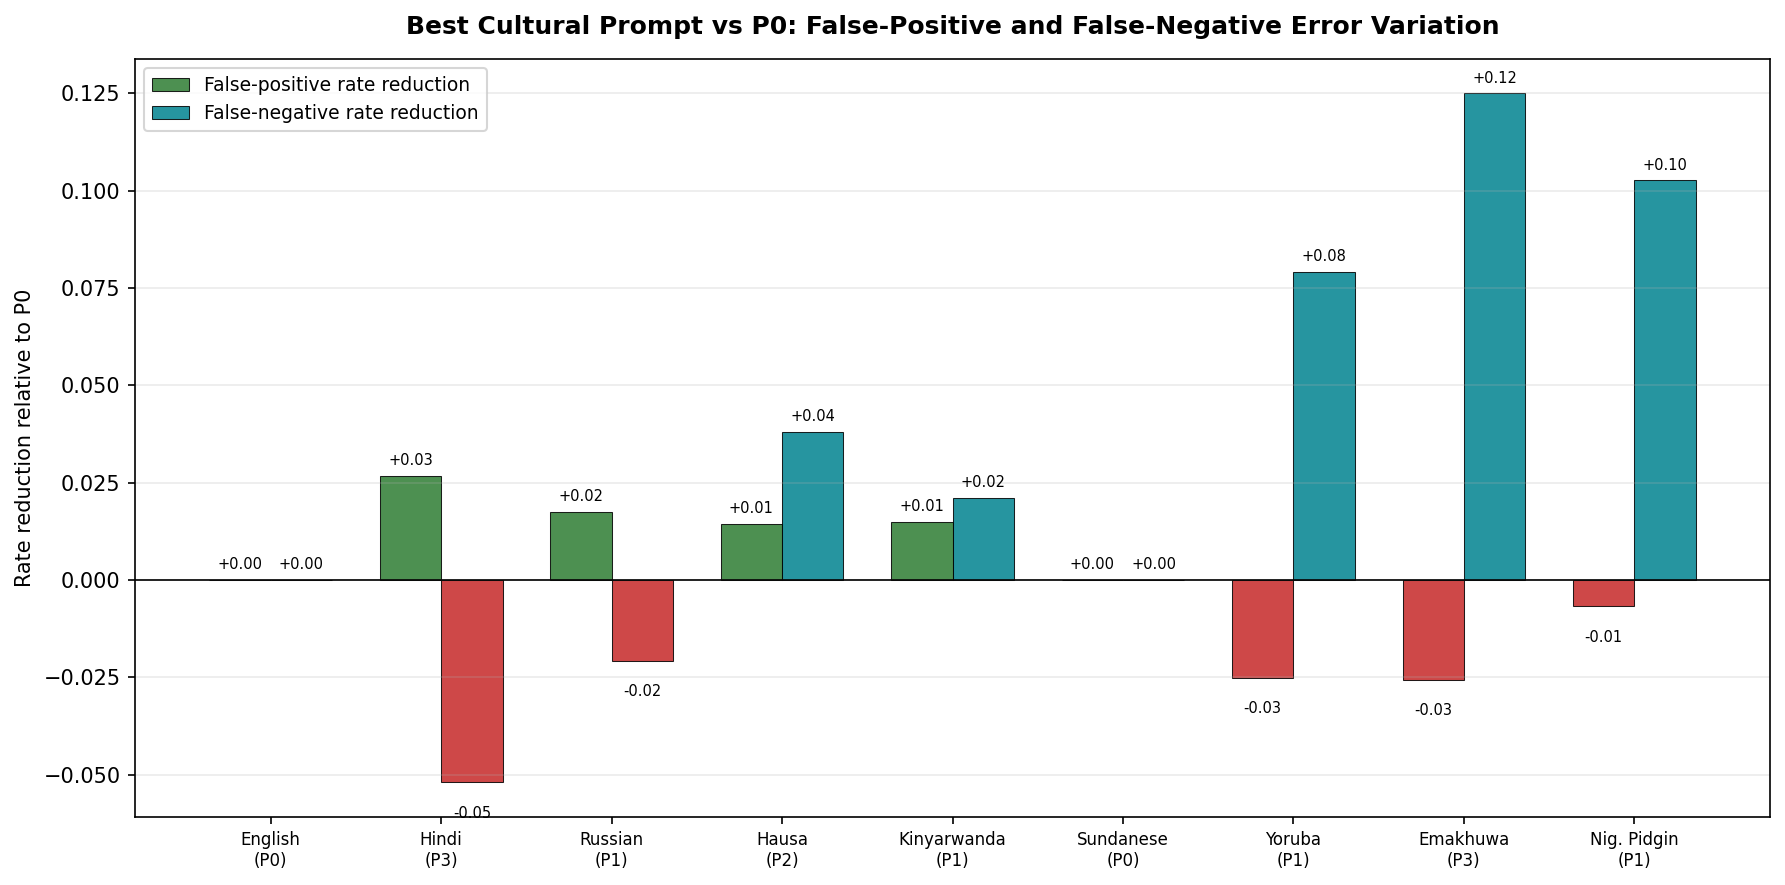

code best_prompt  fp_rate_reduction  fn_rate_reduction
 ENG          P0           0.000000           0.000000
 HIN          P3           0.026769          -0.051948
 RUS          P1           0.017483          -0.020725
 HAU          P2           0.014351           0.038071
 KIN          P1           0.014995           0.021104
 SUN          P0           0.000000           0.000000
 YOR          P1          -0.025204           0.079225
 VMW          P3          -0.025568           0.125000
 PCM          P1          -0.006811           0.102684
Saved fig13 and supporting CSV files


In [ ]:
P2_PRED_DIR = f"{BASE}/Phase2/predictions"

def find_phase2_prediction(lang_code, prompt_key):
    candidates = [
        f"{P2_PRED_DIR}/validation_{lang_code}_prompt_{prompt_key}.json",
        f"{P2_PRED_DIR}/phase2_{lang_code}_{prompt_key}.json",
    ]
    for candidate in candidates:
        if os.path.exists(candidate):
            return candidate
    pattern = os.path.join(P2_PRED_DIR, f"*{lang_code}*{prompt_key}*.json")
    matches = sorted(glob.glob(pattern))
    return matches[0] if matches else None


def load_prediction_payload(path):
    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)
    emotions = list(payload["emotions"])
    order = [emotions.index(e) for e in EMO]
    y_true = np.asarray(payload["y_true"], dtype=int)[:, order]
    y_pred = np.asarray(payload["y_pred"], dtype=int)[:, order]
    return y_true, y_pred


def error_rates(y_true, y_pred):
    fp = int(((y_pred == 1) & (y_true == 0)).sum())
    fn = int(((y_pred == 0) & (y_true == 1)).sum())
    negatives = int((y_true == 0).sum())
    positives = int((y_true == 1).sum())
    fp_rate = fp / negatives if negatives else np.nan
    fn_rate = fn / positives if positives else np.nan
    return fp, fn, fp_rate, fn_rate

error_rows = []
missing_predictions = []
for lang in LO:
    best_prompt = max(["p0", "p1", "p2", "p3"], key=lambda p: p2r[lang][p]["macro_f1"])
    p0_path = find_phase2_prediction(lang, "p0")
    best_path = find_phase2_prediction(lang, best_prompt)

    if p0_path is None or best_path is None:
        missing_predictions.append((lang, p0_path, best_path))
        continue

    y_true_0, y_pred_0 = load_prediction_payload(p0_path)
    y_true_b, y_pred_b = load_prediction_payload(best_path)
    if y_true_0.shape != y_true_b.shape or not np.array_equal(y_true_0, y_true_b):
        raise ValueError(f"Prediction alignment mismatch for {lang}")

    fp0, fn0, fpr0, fnr0 = error_rates(y_true_0, y_pred_0)
    fpb, fnb, fprb, fnrb = error_rates(y_true_b, y_pred_b)

    error_rows.append({
        "language": LN[lang],
        "code": lang.upper(),
        "tier": f"Tier {TI[lang]}",
        "best_prompt": best_prompt.upper(),
        "p0_fp": fp0,
        "best_fp": fpb,
        "p0_fn": fn0,
        "best_fn": fnb,
        "p0_fp_rate": fpr0,
        "best_fp_rate": fprb,
        "p0_fn_rate": fnr0,
        "best_fn_rate": fnrb,
        "fp_rate_reduction": fpr0 - fprb,
        "fn_rate_reduction": fnr0 - fnrb,
    })

if missing_predictions:
    print("Missing Phase 2 prediction files for:")
    for item in missing_predictions:
        print(" ", item)

error_variation = pd.DataFrame(error_rows)
error_variation.to_csv(f"{OUT}/fig13_error_variation_data.csv", index=False)

fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.36
x = np.arange(len(error_variation))
fp_vals = error_variation["fp_rate_reduction"].to_numpy(dtype=float)
fn_vals = error_variation["fn_rate_reduction"].to_numpy(dtype=float)
fp_colors = [CG if value >= 0 else CR for value in fp_vals]
fn_colors = [CT if value >= 0 else CR for value in fn_vals]

ax.bar(x - bar_width / 2, fp_vals, width=bar_width, color=fp_colors, alpha=0.85, label="False-positive rate reduction", edgecolor="black", linewidth=0.5)
ax.bar(x + bar_width / 2, fn_vals, width=bar_width, color=fn_colors, alpha=0.85, label="False-negative rate reduction", edgecolor="black", linewidth=0.5)

for i, (fpv, fnv) in enumerate(zip(fp_vals, fn_vals)):
    ax.text(i - bar_width / 2, fpv + (0.002 if fpv >= 0 else -0.006), f"{fpv:+.2f}", ha="center", va="bottom" if fpv >= 0 else "top", fontsize=7)
    ax.text(i + bar_width / 2, fnv + (0.002 if fnv >= 0 else -0.006), f"{fnv:+.2f}", ha="center", va="bottom" if fnv >= 0 else "top", fontsize=7)

ax.axhline(0, color="black", linewidth=0.8)

ax.set_xticks(x)

ax.set_xticklabels(
    [f"{row.language}\n({row.best_prompt})" for row in error_variation.itertuples()],
    fontsize=8
)
ax.set_ylabel("Rate reduction relative to P0")
ax.set_title("Best Cultural Prompt vs P0: False-Positive and False-Negative Error Variation", fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.25)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT}/fig13_error_variation.png", dpi=300, bbox_inches="tight")
plt.savefig(f"{OUT}/fig13_error_variation.pdf", bbox_inches="tight")
plt.show()

print(error_variation[["code", "best_prompt", "fp_rate_reduction", "fn_rate_reduction"]].to_string(index=False))
print("Saved fig13 and supporting CSV files")
